## 1. Creating the Logistics Dataset

For this project, I created a hypothetical logistics dataset to study delivery performance.

The dataset includes information about delivery distance, shipment volume, transportation cost, delivery time, vehicle type, and traffic level.

I used Python to create 1,000 sample records so that the data could be explored and visualized in the later steps.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "Order_ID": range(1, n + 1),
    "Distance_km": np.random.uniform(1, 30, n).round(2),
    "Shipment_Volume": np.random.randint(1, 20, n),
    "Transportation_Cost": np.random.uniform(50, 500, n).round(2),
    "Delivery_Time_min": np.random.uniform(20, 180, n).round(2),
    "Vehicle_Type": np.random.choice(["Bike", "Van", "Truck"], n),
    "Traffic_Level": np.random.choice(["Low", "Medium", "High"], n)
})

df.head()

,Order_ID,Distance_km,Shipment_Volume,Transportation_Cost,Delivery_Time_min,Vehicle_Type,Traffic_Level
0,1,11.86,15,195.00,60.61,Bike,Low
1,2,28.57,12,106.36,59.33,Van,Low
2,3,22.23,16,263.45,84.44,Truck,High
3,4,18.36,19,101.28,163.14,Van,Low
4,5,5.52,8,268.71,20.07,Van,Medium


## 2. Basic Exploratory Data Analysis

After creating the dataset, I performed some basic exploratory data analysis (EDA).

First, I checked the number of rows and columns, the data types, and the first few records. This helps me understand the structure of the logistics data before performing further analysis.

In [2]:
print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
df.head()

Dataset shape: (1000, 7)

Data types:
Order_ID                 int64
Distance_km            float64
Shipment_Volume          int64
Transportation_Cost    float64
Delivery_Time_min      float64
Vehicle_Type            object
Traffic_Level           object
dtype: object

First 5 rows:


,Order_ID,Distance_km,Shipment_Volume,Transportation_Cost,Delivery_Time_min,Vehicle_Type,Traffic_Level
0,1,11.86,15,195.00,60.61,Bike,Low
1,2,28.57,12,106.36,59.33,Van,Low
2,3,22.23,16,263.45,84.44,Truck,High
3,4,18.36,19,101.28,163.14,Van,Low
4,5,5.52,8,268.71,20.07,Van,Medium


### Basic Statistics

I used descriptive statistics to understand the numerical variables in the dataset.

This gives information such as the average, minimum, maximum, and spread of values for logistics variables like distance, shipment volume, transportation cost, and delivery time.

In [3]:
df.describe()

,Order_ID,Distance_km,Shipment_Volume,Transportation_Cost,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,15.217590,9.926000,277.666840,101.758060
std,288.819436,8.472039,5.446484,131.001999,45.574276
min,1.000000,1.130000,1.000000,50.080000,20.070000
25%,250.750000,7.842500,5.000000,159.712500,63.437500
50%,500.500000,15.405000,10.000000,286.725000,102.985000
75%,750.250000,22.582500,15.000000,389.765000,141.222500
max,1000.000000,29.990000,19.000000,499.870000,179.930000


## 3. Central Tendencies

Central tendency helps us understand the typical values in the logistics dataset.

I calculated the mean, median, and mode for important numerical variables such as distance, shipment volume, transportation cost, and delivery time.

These values help provide a quick summary of the data before moving to distributions and visualizations.

In [4]:
columns = [
    "Distance_km",
    "Shipment_Volume",
    "Transportation_Cost",
    "Delivery_Time_min"
]

for column in columns:
    print("\n", column)
    print("Mean:", round(df[column].mean(), 2))
    print("Median:", round(df[column].median(), 2))
    print("Mode:", df[column].mode()[0])


 Distance_km
Mean: 15.22
Median: 15.41
Mode: 19.37

 Shipment_Volume
Mean: 9.93
Median: 10.0
Mode: 15

 Transportation_Cost
Mean: 277.67
Median: 286.73
Mode: 100.82

 Delivery_Time_min
Mean: 101.76
Median: 102.98
Mode: 21.84


## 4. Distribution of Logistics Variables

I examined the distribution of important numerical variables to understand how their values are spread across the dataset.

Histograms are useful for seeing whether most observations are concentrated in a particular range or spread across different values.

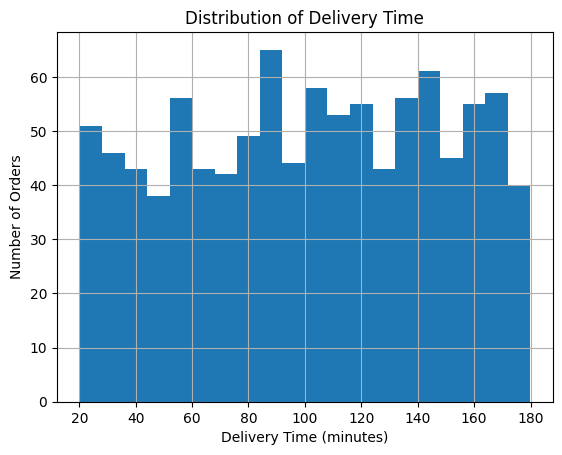

In [9]:
import matplotlib.pyplot as plt

df["Delivery_Time_min"].hist(bins=20)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.show()

## 5. Distribution of Shipment Volume

I used a histogram to understand how shipment volume is distributed across the orders.

This helps identify the range in which most shipment volumes fall.

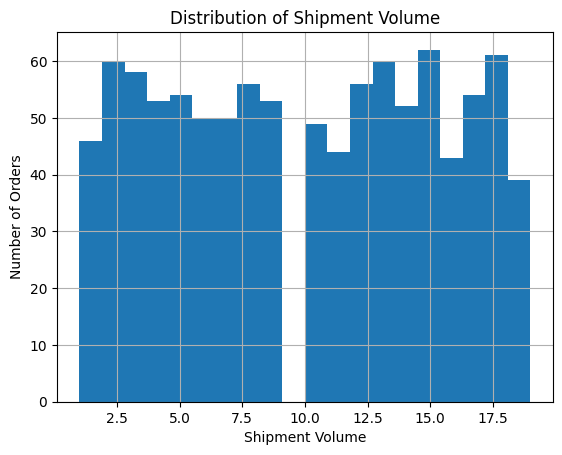

In [10]:
import matplotlib.pyplot as plt

df["Shipment_Volume"].hist(bins=20)

plt.title("Distribution of Shipment Volume")
plt.xlabel("Shipment Volume")
plt.ylabel("Number of Orders")
plt.show()

## 6. Distribution of Transportation Cost

I used a histogram to understand how transportation costs are distributed across the orders.

This helps identify the range in which most transportation costs fall.

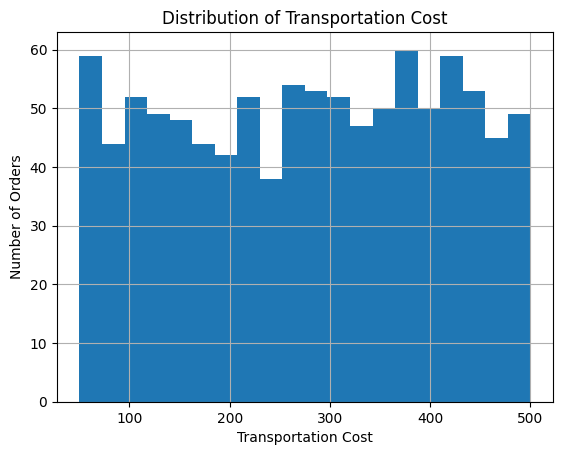

In [11]:
import matplotlib.pyplot as plt

df["Transportation_Cost"].hist(bins=20)

plt.title("Distribution of Transportation Cost")
plt.xlabel("Transportation Cost")
plt.ylabel("Number of Orders")
plt.show()

## 7. Distance and Delivery Time

I used a scatter plot to examine the relationship between delivery distance and delivery time.

This helps me understand whether longer delivery distances are associated with longer delivery times.

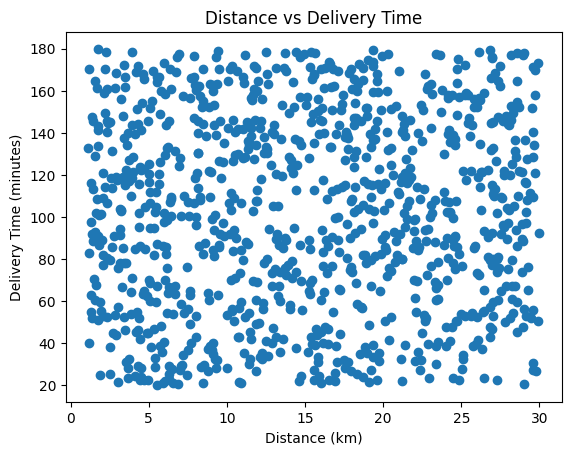

In [12]:
import matplotlib.pyplot as plt

plt.scatter(df["Distance_km"], df["Delivery_Time_min"])

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

## 8. Shipment Volume and Transportation Cost

I used a scatter plot to examine the relationship between shipment volume and transportation cost.

This helps me understand whether larger shipment volumes are associated with higher transportation costs.

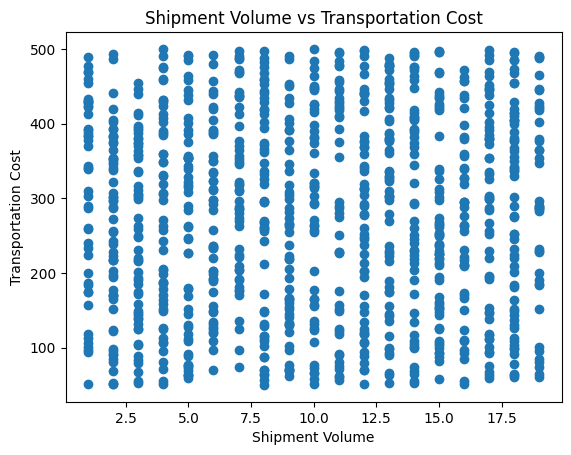

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df["Shipment_Volume"], df["Transportation_Cost"])

plt.title("Shipment Volume vs Transportation Cost")
plt.xlabel("Shipment Volume")
plt.ylabel("Transportation Cost")
plt.show()

## 9. Delivery Time by Vehicle Type

I used a box plot to compare delivery times for different vehicle types.

This helps me understand how delivery time varies across bikes, vans, and trucks and whether some vehicle types have more variation in delivery time.

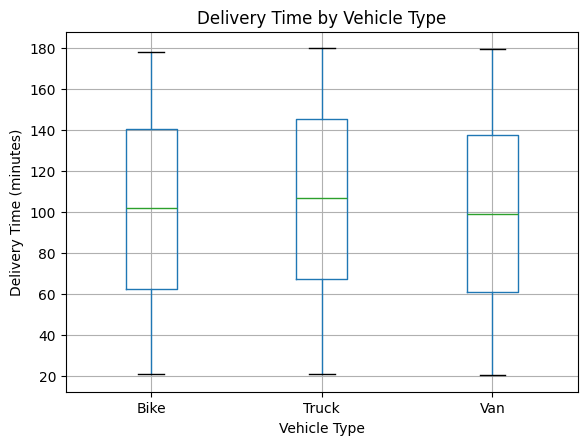

In [14]:
import matplotlib.pyplot as plt

df.boxplot(column="Delivery_Time_min", by="Vehicle_Type")

plt.title("Delivery Time by Vehicle Type")
plt.suptitle("")
plt.xlabel("Vehicle Type")
plt.ylabel("Delivery Time (minutes)")
plt.show()

## 10. Delivery Time by Traffic Level

I used a box plot to compare delivery times across different traffic levels.

This helps me understand how delivery time varies when traffic conditions are low, medium, or high.

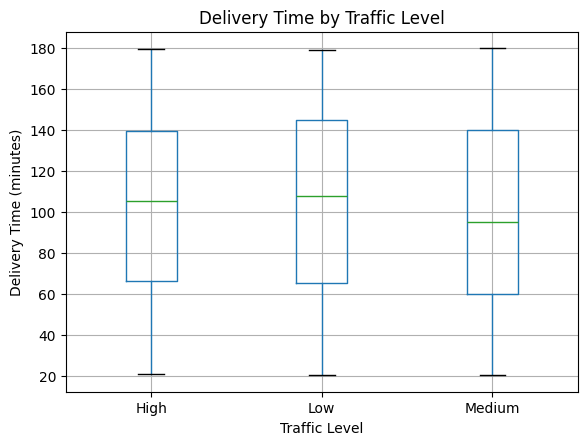

In [15]:
import matplotlib.pyplot as plt

df.boxplot(column="Delivery_Time_min", by="Traffic_Level")

plt.title("Delivery Time by Traffic Level")
plt.suptitle("")
plt.xlabel("Traffic Level")
plt.ylabel("Delivery Time (minutes)")
plt.show()

## 11. Correlation Analysis

I used a correlation matrix to understand the relationships between the numerical variables in the dataset.

Correlation helps show whether two variables tend to increase or decrease together. This can help identify relationships that may be useful for understanding logistics performance.

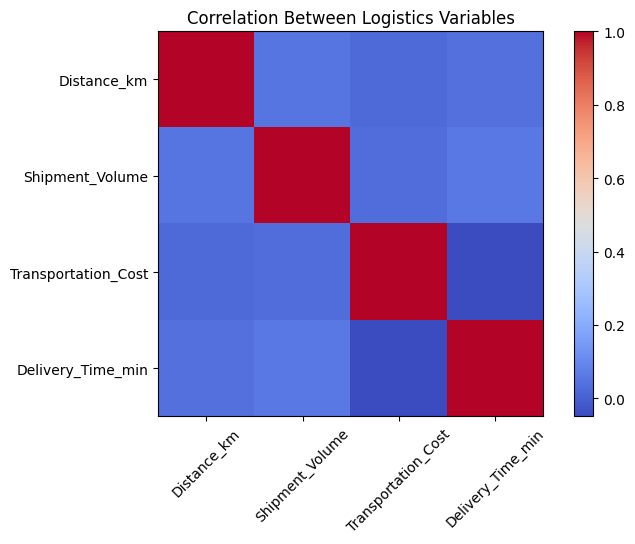

In [16]:
import matplotlib.pyplot as plt

correlation = df[
    [
        "Distance_km",
        "Shipment_Volume",
        "Transportation_Cost",
        "Delivery_Time_min"
    ]
].corr()

plt.figure(figsize=(8, 5))
plt.imshow(correlation, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Between Logistics Variables")
plt.show()

## 12. Average Delivery Time by Traffic Level

I calculated the average delivery time for each traffic level and used a bar chart to compare them.

This helps me understand how traffic conditions may affect average delivery performance.

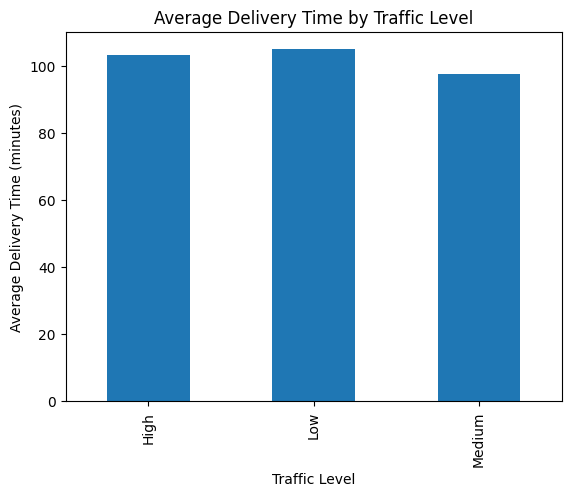

In [17]:
import matplotlib.pyplot as plt

avg_delivery = df.groupby("Traffic_Level")["Delivery_Time_min"].mean()

avg_delivery.plot(kind="bar")

plt.title("Average Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (minutes)")
plt.show()

## 13. Average Transportation Cost by Vehicle Type

I calculated the average transportation cost for each vehicle type.

I used a bar chart to compare the average cost of Bike, Van, and Truck.

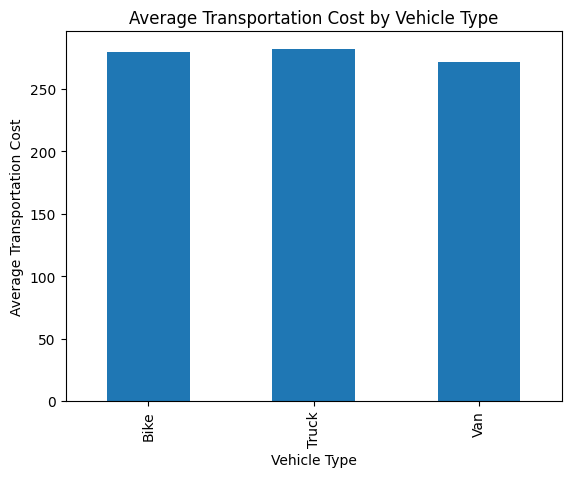

In [18]:
import matplotlib.pyplot as plt

avg_cost = df.groupby("Vehicle_Type")["Transportation_Cost"].mean()

avg_cost.plot(kind="bar")

plt.title("Average Transportation Cost by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Transportation Cost")
plt.show()

## 14. Average Shipment Volume by Vehicle Type

I calculated the average shipment volume for each vehicle type.

I used a bar chart to compare the average shipment volume handled by Bike, Van, and Truck.

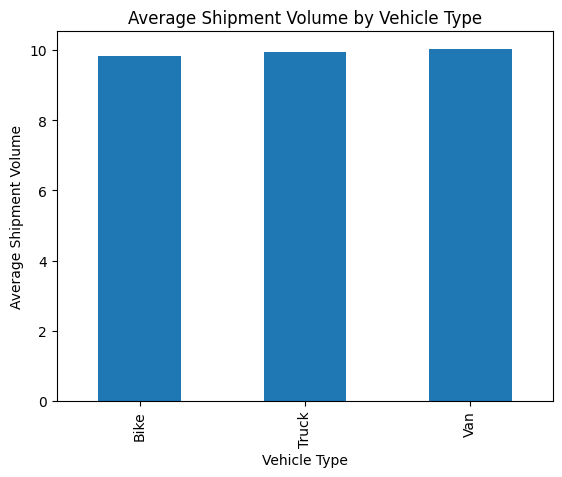

In [19]:
import matplotlib.pyplot as plt

avg_volume = df.groupby("Vehicle_Type")["Shipment_Volume"].mean()

avg_volume.plot(kind="bar")

plt.title("Average Shipment Volume by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Shipment Volume")
plt.show()

## 15. Average Delivery Time by Vehicle Type

I calculated the average delivery time for each vehicle type.

I used a bar chart to compare the average delivery time for Bike, Van, and Truck.

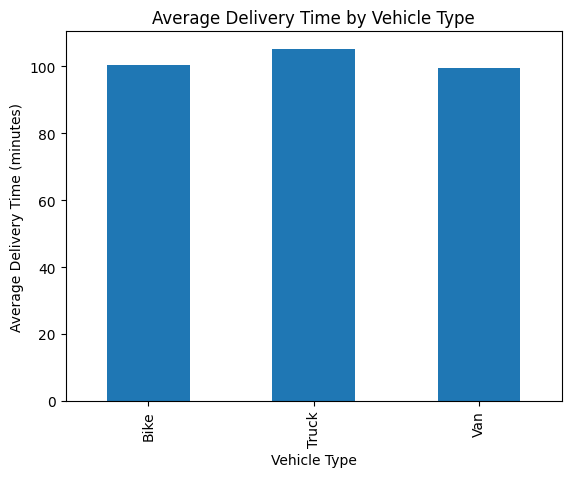

In [20]:
import matplotlib.pyplot as plt

avg_time = df.groupby("Vehicle_Type")["Delivery_Time_min"].mean()

avg_time.plot(kind="bar")

plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time (minutes)")
plt.show()

## 16. Average Transportation Cost by Traffic Level

I calculated the average transportation cost for each traffic level.

I used a bar chart to compare the average transportation cost under Low, Medium, and High traffic.

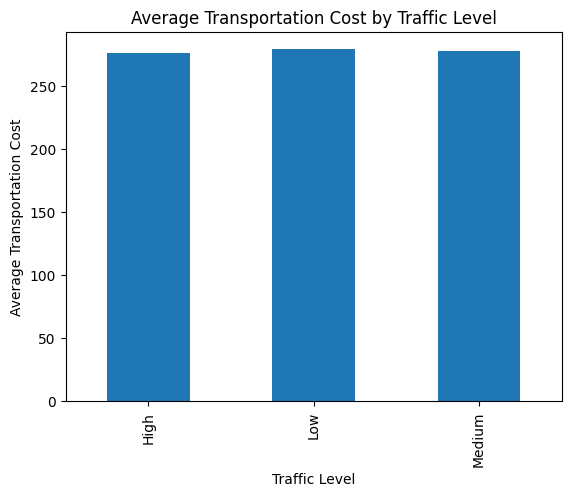

In [21]:
import matplotlib.pyplot as plt

avg_cost = df.groupby("Traffic_Level")["Transportation_Cost"].mean()

avg_cost.plot(kind="bar")

plt.title("Average Transportation Cost by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Average Transportation Cost")
plt.show()

## 17. Average Shipment Volume by Vehicle Type

I calculated the average shipment volume for each vehicle type.

This helps me compare the amount of shipment handled by different vehicle types.

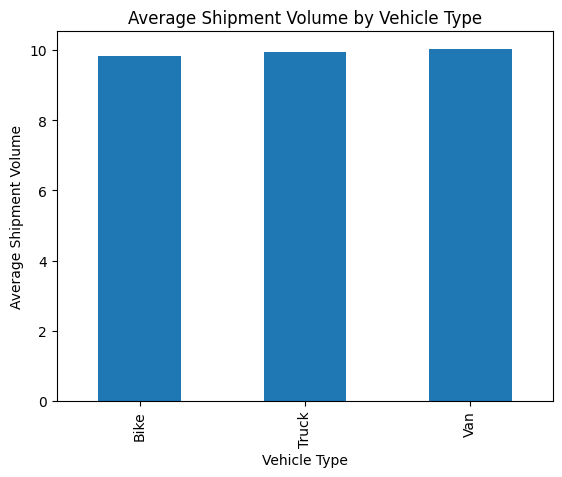

In [22]:
import matplotlib.pyplot as plt

avg_volume = df.groupby("Vehicle_Type")["Shipment_Volume"].mean()

avg_volume.plot(kind="bar")

plt.title("Average Shipment Volume by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Shipment Volume")
plt.show()

## 18. Distance and Transportation Cost

I used a scatter plot to examine the relationship between distance and transportation cost.

This helps me understand whether transportation cost changes with delivery distance.

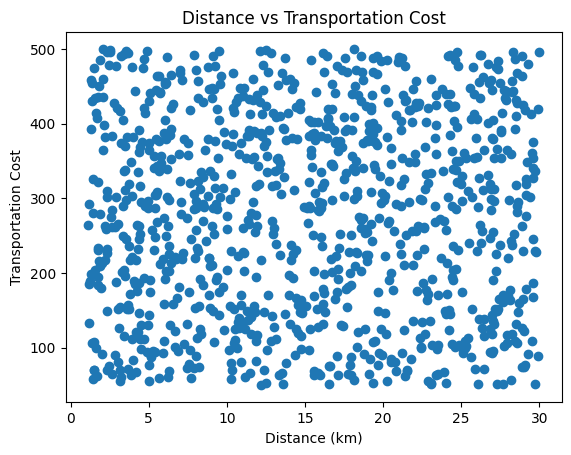

In [23]:
import matplotlib.pyplot as plt

plt.scatter(df["Distance_km"], df["Transportation_Cost"])

plt.title("Distance vs Transportation Cost")
plt.xlabel("Distance (km)")
plt.ylabel("Transportation Cost")
plt.show()

## 19. Average Delivery Time by Vehicle Type and Traffic Level

I calculated the average delivery time for each vehicle type under different traffic levels.

This helps me compare delivery performance across both vehicle type and traffic conditions.

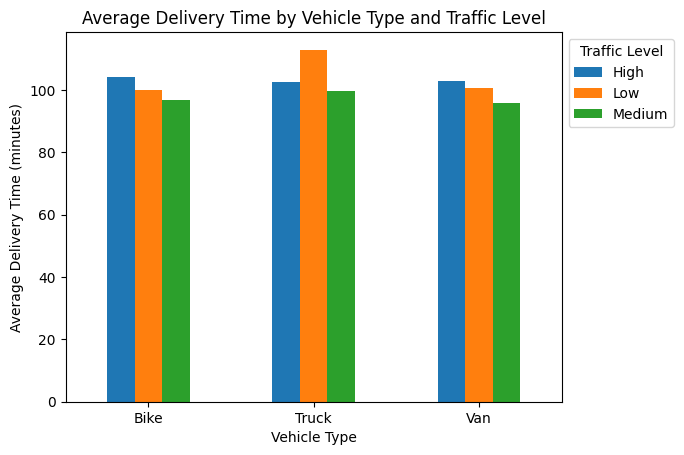

In [27]:
import matplotlib.pyplot as plt

avg_time = df.groupby(
    ["Vehicle_Type", "Traffic_Level"]
)["Delivery_Time_min"].mean().unstack()

avg_time.plot(kind="bar")

plt.title("Average Delivery Time by Vehicle Type and Traffic Level")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.legend(title="Traffic Level", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

## 20. Average Transportation Cost by Vehicle Type and Traffic Level

I calculated the average transportation cost for each vehicle type under different traffic levels.

This helps me compare transportation costs across different vehicle and traffic combinations.

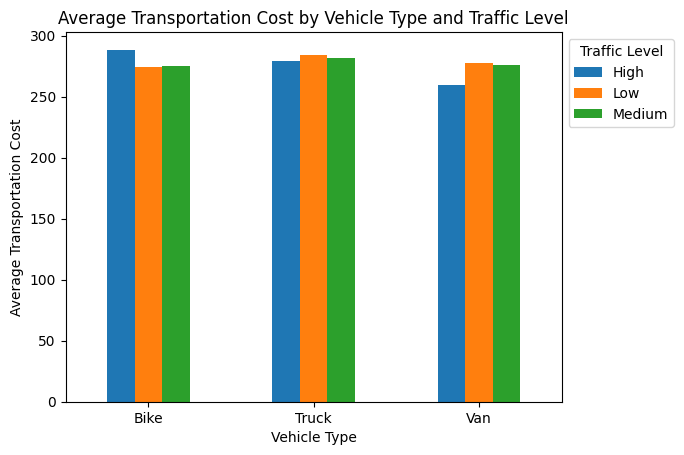

In [26]:
import matplotlib.pyplot as plt

avg_cost = df.groupby(
    ["Vehicle_Type", "Traffic_Level"]
)["Transportation_Cost"].mean().unstack()

avg_cost.plot(kind="bar")

plt.title("Average Transportation Cost by Vehicle Type and Traffic Level")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Transportation Cost")
plt.xticks(rotation=0)
plt.legend(title="Traffic Level", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

## 21. Overall Logistics Summary

I calculated the average values of the main logistics variables.

This gives a simple overall view of distance, shipment volume, transportation cost, and delivery time in the dataset.

In [28]:
print("Average Distance:", round(df["Distance_km"].mean(), 2), "km")
print("Average Shipment Volume:", round(df["Shipment_Volume"].mean(), 2))
print("Average Transportation Cost:", round(df["Transportation_Cost"].mean(), 2))
print("Average Delivery Time:", round(df["Delivery_Time_min"].mean(), 2), "minutes")

Average Distance: 15.22 km
Average Shipment Volume: 9.93
Average Transportation Cost: 277.67
Average Delivery Time: 101.76 minutes


## 22. Key Analytical Insights

Based on the analysis and visualizations, I identified some important points about the logistics dataset.

- The average delivery distance is 15.22 km.
- The average shipment volume is 9.93 units.
- The average transportation cost is 277.67.
- The average delivery time is 101.76 minutes.

The visualizations also helped me compare delivery time, transportation cost, shipment volume, vehicle types, and traffic levels.

## 23. Delivery Time Observations

* The delivery time analysis helped me understand how delivery time varies across the dataset.

* The distribution chart shows how delivery times are spread across different ranges.

* The comparison by traffic level helps identify differences in delivery time under Low, Medium, and High traffic conditions.

* The comparison by vehicle type also helps understand how delivery time varies between different vehicle types.

## 24. Transportation Cost Observations

* The transportation cost analysis helped me understand how costs are distributed and how they vary across different logistics factors.

* The transportation cost distribution shows the range of costs across the orders.

* The comparison by vehicle type helps understand the difference in average transportation cost between Bike, Van, and Truck.

* The comparison by traffic level also helps examine how transportation costs vary under different traffic conditions.

## 25. Shipment Volume Observations

* The shipment volume analysis helped me understand how many units are handled in different orders.

* The distribution chart shows the range of shipment volumes in the dataset.

* The comparison by vehicle type helps me understand the average shipment volume handled by Bike, Van, and Truck.

* These observations can be useful for understanding how shipment volume is distributed across different vehicle types.

## 26. Relationship and Correlation Observations

* I used scatter plots and a correlation matrix to examine relationships between the main numerical variables.

* The scatter plots help visually compare variables such as distance, delivery time, shipment volume, and transportation cost.

* The correlation matrix gives a numerical value for each pair of variables, making it easier to identify whether the relationships are weak or strong.

* These results help provide a better understanding of how the main logistics variables are related to each other.

## 27. Bottlenecks and Operational Efficiency

* The analysis helps identify areas that may affect logistics performance.

* Delivery time can be monitored to identify orders that take longer than expected.

* Transportation cost can be compared across different vehicle types and traffic levels to understand cost differences.

* Shipment volume can also be considered when planning vehicle usage and delivery operations.

* These observations can help a logistics team monitor delivery performance, control transportation costs, and plan resources more effectively.

## 28. Recommendations

Based on the analysis, the following recommendations can help improve logistics operations:

- Monitor delivery times regularly to identify delays and improve delivery performance.
- Compare transportation costs across different vehicle types to support better vehicle planning.
- Consider traffic conditions while planning deliveries, especially when delivery time is important.
- Use shipment volume information to plan vehicle usage and avoid inefficient allocation of resources.
- Continue tracking distance, delivery time, shipment volume, and transportation cost to support future logistics decisions.

## 29. Conclusion

In this project, I created and analyzed a hypothetical logistics dataset using Python.

* I performed exploratory data analysis to understand delivery distance, shipment volume, transportation cost, and delivery time.

* I used different visualizations such as histograms, scatter plots, box plots, bar charts, and a correlation matrix to understand the data from different perspectives.

* The analysis helped me identify patterns and compare logistics performance across vehicle types and traffic levels.

Overall, this project helped me understand how Python-based data analysis and visualization can be used to study logistics operations and support data-driven decisions.